[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mihirathavale96/Guided_growth_BO_tutorial/blob/main/bayesian_optimization_device_growth.ipynb)

#  🔬📈Bayesian Optimization for Epitaxial Device Growth

**A self-contained tutorial **

Toy nanowire-like growth → DoE warm-start with single-objective BO and multi-objective BO → real InP/InAsP MQW microring laser pipeline.

---

### ▶ How to use this notebook

> This is a **step-by-step tutorial** — read each section, then run the cell beneath it.


1. Run **Section 0 (Setup cell)** first, then **Runtime → Restart session** once
2. Work through each section in order — read, then run
3. Drag the 🔬 **sliders** and re-run to experiment
4. Follow the 💬 **"Try it"** prompts n

---

🔗 Multi quantum well microring (MQW MR) pipeline → [github.com/OMS-lab/Microring_MOBO](https://github.com/OMS-lab/Microring_MOBO) &nbsp;·&nbsp; BO templates → [honegumi.readthedocs.io](https://honegumi.readthedocs.io)

---

*The five steps of this tutorial — the first four give introduction and use a fast toy simulator; the last one onnect to the real MQW MRs pipeline.*

---
## 📦 Section 0 · Setup

> ⚠️ **Run this cell once, then do Runtime → Restart session before continuing.**
>
> The version pins below are required — without them Ax crashes silently.
> After the restart you will see *"Your session crashed"* — that is expected.
> Then continue to Section 1 and run cells one by one.

In [1]:
#@title  { display-mode: "form" }

import importlib, subprocess, sys, os

def _need_install():
    """Return True if any required package is missing or wrong version."""
    try:
        import numpy as np
        if int(np.__version__.split(".")[0]) >= 2:
            return True

        import pandas as pd
        if int(pd.__version__.split(".")[0]) >= 3:
            return True

        import ax
        return False

    except Exception:
        return True


if _need_install():
    print("Installing required packages. This may take around 60 seconds...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "ax-platform==0.5.0",
        "botorch==0.13.0",
        "numpy<2",
        "pandas<2.3"
    ])

    print("Installation complete. Restarting runtime...")
    os.kill(os.getpid(), 9)

else:
    print("✅ Setup complete. You can run the rest of the notebook.")

✅ Setup complete. You can run the rest of the notebook.


---
## 🧭 Section 1 · What is Bayesian Optimization?

### The problem
You want the best growth recipe. Each experiment is slow and expensive.
You cannot afford to search the whole space — so you need to be *smart* about which recipe to try next.

### What BO does
BO keeps a **probabilistic model** of the recipe → performance map and uses it to pick the most informative next experiment every time.

| Step | What happens | In plain words |
|---|---|---|
| ① Propose | Acquisition function scores all untried recipes | "Which recipe would teach us the most?" |
| ② Run | Grow the device, measure the result | One real (or simulated) experiment |
| ③ Update | Gaussian process surrogate is refitted | "Now I know a bit more about the landscape" |
| ④ Repeat | Until budget is spent | Each run is smarter than the last |

![BO loop](https://raw.githubusercontent.com/mihirathavale96/Guided_growth_BO_tutorial/main/fig_boloop_2.png)

*The BO loop: the model proposes a recipe → you grow and measure → the model updates → repeat.*

### Explore vs exploit
The surrogate model predicts performance **and** its own uncertainty.
It balances trying recipes it *thinks* are good (exploit) against regions it knows little about (explore) — this is why BO beats random search in so few experiments.

![Explore vs exploit](https://raw.githubusercontent.com/mihirathavale96/Guided_growth_BO_tutorial/main/fig_explore.png)

*Wide blue band = high uncertainty = explore here. Coral dots = experiments run so far.*

### Pareto front *(multi-objective only)*
When two goals conflict there is no single "best". The **Pareto front** is the set of recipes where you cannot improve one goal without hurting the other. We cover this in Section 6.


---
## 🧪 Section 2 · The toy growth problem

Instead of a real MOVPE/MOCVD system, we use a **toy simulator** — a simplified III–V epitaxial growth problem where you tune a few growth knobs to optimise photoluminescence (PL) intensity and emission wavelength.

In Section 7, we connect this idea to the actual **InP/InAsP MQW microring laser** data.

### Growth knobs

| Knob | What it represents | Range |
|---|---|---|
| `growth_temp` | Growth temperature | 480–560 °C |
| `v_iii_ratio` | Total group-V / group-III precursor ratio | 5–50 |
| `AsH3_fraction` | Fraction of group-V hydride flow supplied as AsH₃: AsH₃/(AsH₃ + PH₃) | 0.10–0.50 |

### Optimisation outputs

| Output | We want it… | Why |
|---|---|---|
| **PL intensity** (a.u.) | **High** | Proxy for optical/material quality before lasing |
| **Emission wavelength** (nm) | **At least 1260 nm** | 1260 nm is the lower edge of the communication O-band |

### Key challenge

- Many growth recipes produce measurable PL, but only a narrow region gives both **high PL intensity** and **emission wavelength ≥1260 nm**.
- Increasing the **AsH₃ fraction** or changing the **growth temperature** can push the emission to longer wavelength.
- However, this can also move the recipe away from the highest-PL growth window.
- Bayesian optimisation helps find recipes that satisfy both requirements without testing every possible growth condition.

▶ **Run the cell below** to define the simulator and see the landscape.



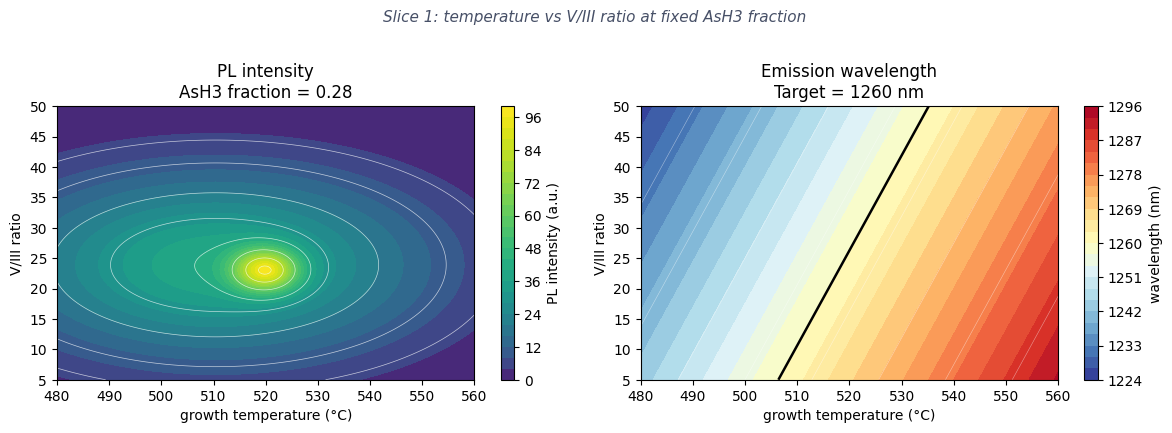

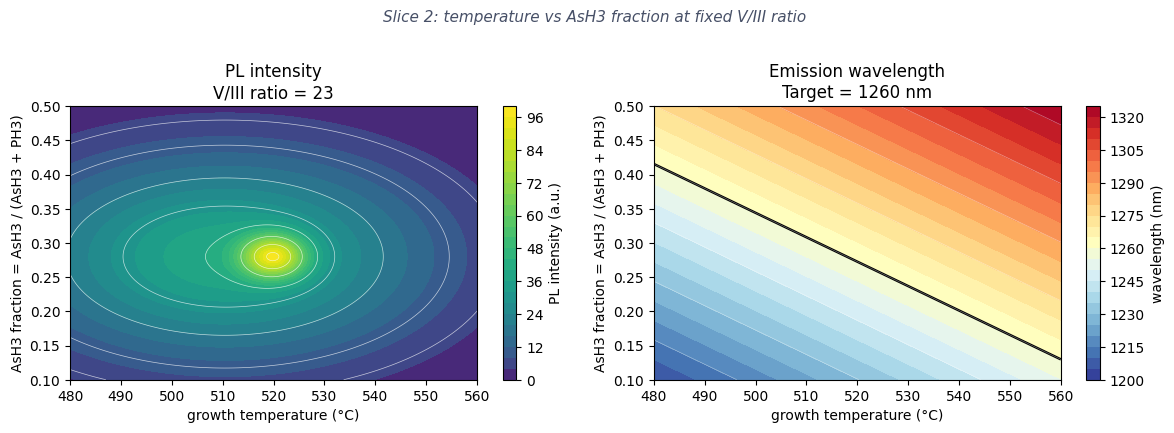

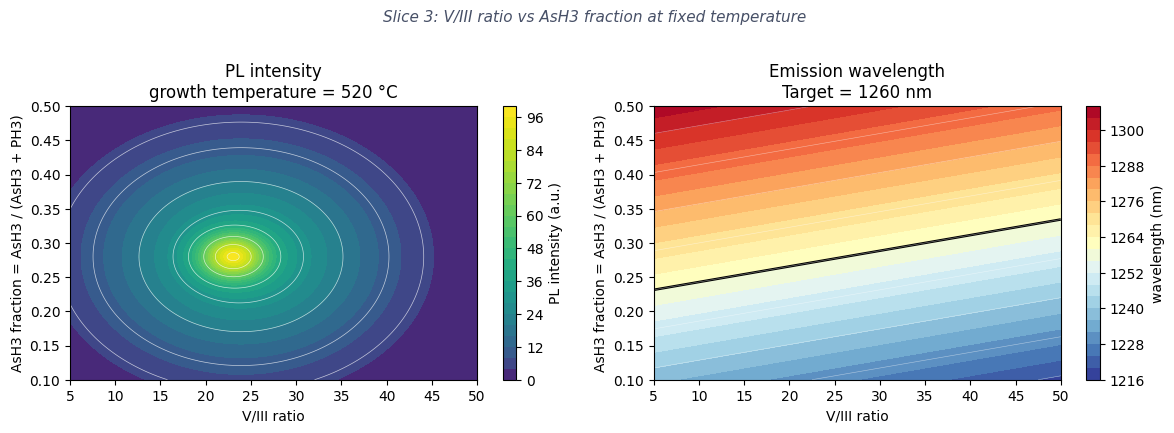

In [ ]:
#@title  { display-mode: "form" }

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

def device_response(growth_temp, v_iii_ratio, AsH3_fraction, noise=True, rng=np.random):
    # Rescale inputs to roughly 0–1
    t = (growth_temp - 480) / 80.0       # 480–560 °C
    v = (v_iii_ratio - 5) / 45.0         # 5–50
    a = (AsH3_fraction - 0.10) / 0.40    # 0.10–0.50

    # Broad PL background:
    # many recipes give some PL, so the landscape is visible.
    broad_growth_window = 40 * np.exp(
        -((t - 0.38)**2) / 0.22
        -((v - 0.42)**2) / 0.10
        -((a - 0.45)**2) / 0.12
    )

    # High-quality growth window:
    # still narrow, but broad enough that BO can learn it with a sensible budget.
    high_quality_peak = 60 * np.exp(
        -((t - 0.50)**2) / 0.006
        -((v - 0.40)**2) / 0.006
        -((a - 0.45)**2) / 0.006
    )

    pl = min(broad_growth_window + high_quality_peak, 100)

    # Emission wavelength:
    # higher temperature and higher AsH3 fraction push wavelength longer.
    # higher V/III slightly pulls wavelength shorter in this toy model.
    wl = 1212 + 50*t - 18*v + 70*a

    if noise:
        pl += rng.normal(0, 2.0)
        wl += rng.normal(0, 1.5)

    return float(max(pl, 0.0)), float(wl)


T = np.linspace(480, 560, 180)
V = np.linspace(5, 50, 180)
AsH3 = np.linspace(0.10, 0.50, 180)

fixed_T = 520
fixed_V = 23
fixed_AsH3_fraction = 0.28

target = 1260


def plot_landscape(ax_pl, ax_wl, X, Y, PL, WL, xlabel, ylabel, title_suffix):
    c1 = ax_pl.contourf(
        X, Y, PL,
        levels=np.linspace(0, 100, 26),
        cmap="viridis",
        norm=PowerNorm(gamma=0.55, vmin=0, vmax=100)
    )

    ax_pl.contour(
        X, Y, PL,
        levels=[5, 10, 20, 30, 40, 60, 80, 95],
        colors="white",
        linewidths=0.5,
        alpha=0.7
    )

    ax_pl.set_xlabel(xlabel)
    ax_pl.set_ylabel(ylabel)
    ax_pl.set_title(f"PL intensity\n{title_suffix}")
    plt.colorbar(c1, ax=ax_pl, label="PL intensity (a.u.)")

    c2 = ax_wl.contourf(
        X, Y, WL,
        levels=24,
        cmap="RdYlBu_r"
    )

    ax_wl.contour(
        X, Y, WL,
        levels=[target],
        colors="black",
        linewidths=1.8
    )

    ax_wl.contour(
        X, Y, WL,
        levels=8,
        colors="white",
        linewidths=0.4,
        alpha=0.5
    )

    ax_wl.set_xlabel(xlabel)
    ax_wl.set_ylabel(ylabel)
    ax_wl.set_title(f"Emission wavelength\nTarget = {target} nm")
    plt.colorbar(c2, ax=ax_wl, label="wavelength (nm)")


# Plot 1: temperature vs V/III, fixed AsH3 fraction
TT, VV = np.meshgrid(T, V)

PL_TV = np.array([
    [device_response(tt, vv, fixed_AsH3_fraction, noise=False)[0] for tt in T]
    for vv in V
])

WL_TV = np.array([
    [device_response(tt, vv, fixed_AsH3_fraction, noise=False)[1] for tt in T]
    for vv in V
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

plot_landscape(
    ax1, ax2,
    TT, VV,
    PL_TV, WL_TV,
    xlabel="growth temperature (°C)",
    ylabel="V/III ratio",
    title_suffix=f"AsH3 fraction = {fixed_AsH3_fraction:.2f}"
)

plt.suptitle(
    "Slice 1: temperature vs V/III ratio at fixed AsH3 fraction",
    fontsize=11,
    style="italic",
    color="#475067",
    y=1.02
)

plt.tight_layout()
plt.show()


# Plot 2: temperature vs AsH3 fraction, fixed V/III
TT, AA = np.meshgrid(T, AsH3)

PL_TA = np.array([
    [device_response(tt, fixed_V, aa, noise=False)[0] for tt in T]
    for aa in AsH3
])

WL_TA = np.array([
    [device_response(tt, fixed_V, aa, noise=False)[1] for tt in T]
    for aa in AsH3
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

plot_landscape(
    ax1, ax2,
    TT, AA,
    PL_TA, WL_TA,
    xlabel="growth temperature (°C)",
    ylabel="AsH3 fraction = AsH3 / (AsH3 + PH3)",
    title_suffix=f"V/III ratio = {fixed_V}"
)

plt.suptitle(
    "Slice 2: temperature vs AsH3 fraction at fixed V/III ratio",
    fontsize=11,
    style="italic",
    color="#475067",
    y=1.02
)

plt.tight_layout()
plt.show()


# Plot 3: V/III vs AsH3 fraction, fixed temperature
VV, AA = np.meshgrid(V, AsH3)

PL_VA = np.array([
    [device_response(fixed_T, vv, aa, noise=False)[0] for vv in V]
    for aa in AsH3
])

WL_VA = np.array([
    [device_response(fixed_T, vv, aa, noise=False)[1] for vv in V]
    for aa in AsH3
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

plot_landscape(
    ax1, ax2,
    VV, AA,
    PL_VA, WL_VA,
    xlabel="V/III ratio",
    ylabel="AsH3 fraction = AsH3 / (AsH3 + PH3)",
    title_suffix=f"growth temperature = {fixed_T} °C"
)

plt.suptitle(
    "Slice 3: V/III ratio vs AsH3 fraction at fixed temperature",
    fontsize=11,
    style="italic",
    color="#475067",
    y=1.02
)

plt.tight_layout()
plt.show()

### 🔬 Try a growth recipe by hand

Drag the sliders below and run the cell. Try to score above 70 on **both** metrics at once.
The difficulty you feel is exactly the problem BO is designed to solve.

In [ ]:
#@title  { display-mode: "form" }

growth_temp   = 554   #@param {type:"slider", min:480, max:560, step:2}
v_iii_ratio   = 45    #@param {type:"slider", min:5,   max:50,  step:1}
AsH3_fraction = 0.48  #@param {type:"slider", min:0.10, max:0.50, step:0.02}

show_hint = True     #@param {type:"boolean"}

target = 1260

pl, wl = device_response(growth_temp, v_iii_ratio, AsH3_fraction, noise=False)

score_pl = round(100 * (min(pl, 100) / 100)**2)

score_wl = 100 if wl >= target else max(0, round(100 - 20*(target - wl)))

bar_pl = "█" * (score_pl // 5) + "░" * (20 - score_pl // 5)
bar_wl = "█" * (score_wl // 5) + "░" * (20 - score_wl // 5)

if wl >= target:
    wl_note = "✅ in band"
elif wl >= target - 3:
    wl_note = "🟡 just short"
else:
    wl_note = "🔴 too short"

combined = min(score_pl, score_wl)

print(f"Recipe:  T = {growth_temp} °C   V/III = {v_iii_ratio}   AsH3 fraction = {AsH3_fraction:.2f}")
print("────────────────────────────────────────────────────────────")
print(f"PL intensity     = {pl:5.1f} a.u.   {'🟢 bright' if pl > 70 else '🟡 ok' if pl > 40 else '🔴 dim'}")
print(f"Emission λ       = {wl:5.1f} nm    target ≥ {target} nm   {wl_note}")
print("────────────────────────────────────────────────────────────")
print(f"PL score     [{bar_pl}] {score_pl}/100")
print(f"Wavel. score [{bar_wl}] {score_wl}/100")
print(f"Combined     = {combined}/100   ← try to beat 70  (harder than it looks!)")

if show_hint:
    print("\n💡 Hint")
    print("A good recipe needs BOTH high PL and wavelength ≥ 1260 nm.")
    print("Try around:")
    print("  T ≈ 520 °C")
    print("  V/III ≈ 22–24")
    print("  AsH3 fraction ≈ 0.28")
    print()
    print("Recipes that beat 70 are approximately:")
    print("  520 °C, V/III = 23, AsH3 fraction = 0.28")
    print("  520 °C, V/III = 24, AsH3 fraction = 0.28")

Recipe:  T = 554 °C   V/III = 45   AsH3 fraction = 0.48
────────────────────────────────────────────────────────────
PL intensity     =   0.1 a.u.   🔴 dim
Emission λ       = 1308.8 nm    target ≥ 1260 nm   ✅ in band
────────────────────────────────────────────────────────────
PL score     [░░░░░░░░░░░░░░░░░░░░] 0/100
Wavel. score [████████████████████] 100/100
Combined     = 0/100   ← try to beat 70  (harder than it looks!)

💡 Hint
A good recipe needs BOTH high PL and wavelength ≥ 1260 nm.
Try around:
  T ≈ 520 °C
  V/III ≈ 22–24
  AsH3 fraction ≈ 0.28

Recipes that beat 70 are approximately:
  520 °C, V/III = 23, AsH3 fraction = 0.28
  520 °C, V/III = 24, AsH3 fraction = 0.28




---
## 📐 Section 3 · Design of Experiments — a smart first batch

Before Bayesian optimisation can make useful decisions, it needs an initial set of measurements.  
This first batch should cover the growth space well, so the model has a sensible starting picture of the system.

| Strategy | What happens |
|---|---|
| ❌ **Random sampling** | Points can clump together, leaving large regions unexplored |
| ⚠️ **Full-factorial grid** | Covers the space systematically, but the number of runs grows quickly as more knobs or levels are added |
| ✅ **Latin Hypercube Sampling (LHS)** | Spreads points across each knob range, giving good coverage with fewer runs |

![DoE comparison](https://raw.githubusercontent.com/mihirathavale96/Guided_growth_BO_tutorial/main/fig_doe_compare_v2.png)

*Same number of runs: 8. All panels use the same temperature–V/III grid. In the LHS panel, each temperature column and each V/III row contains exactly one point. In the full toy problem, the same idea is applied across all three knobs: `growth_temp`, `v_iii_ratio`, and `AsH3_fraction`.*

A full-factorial grid becomes expensive very quickly. For example, using only 4 levels for each of 3 knobs already requires:

```text
4 × 4 × 4 = 64 runs

Latin-Hypercube Design of Experiments
─────────────────────────────────────
Number of DoE runs = 13
  → Initial recipes measured before BO starts.

DoE seed = 4
  → Controls the random LHS arrangement.
  → Same seed = same starting batch; different seed = different LHS batch.

Coverage score, lower = more even:
  LHS    = 0.0107
  Random = 0.0492


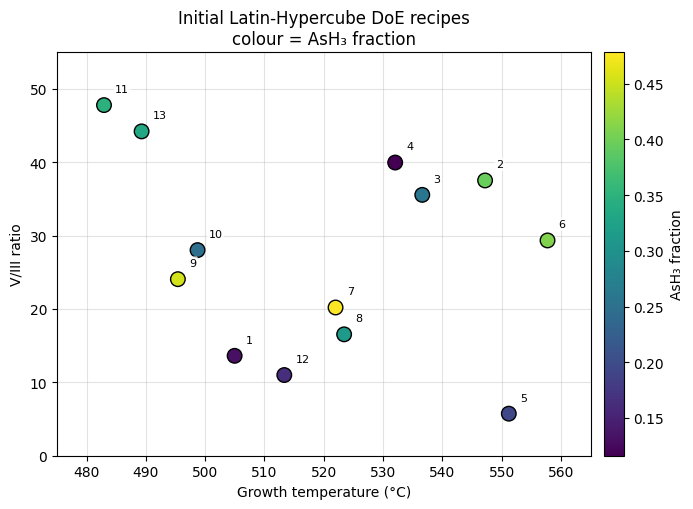

In [ ]:
#@title Generate Latin-Hypercube DoE { display-mode: "form" }

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from IPython.display import display

# ── USER CONTROLS ────────────────────────────────────────────────────────────
n_doe    = 13   #@param {type:"slider", min:4, max:20, step:1}
doe_seed = 4   #@param {type:"integer"}
show_table = False  #@param {type:"boolean"}

print("Latin-Hypercube Design of Experiments")
print("─────────────────────────────────────")
print(f"Number of DoE runs = {n_doe}")
print("  → Initial recipes measured before BO starts.")
print()
print(f"DoE seed = {doe_seed}")
print("  → Controls the random LHS arrangement.")
print("  → Same seed = same starting batch; different seed = different LHS batch.")

# ── PARAMETER BOUNDS ─────────────────────────────────────────────────────────
lows  = np.array([480.0,  5.0, 0.10])
highs = np.array([560.0, 50.0, 0.50])

names = [
    "growth_temp",
    "v_iii_ratio",
    "AsH3_fraction"
]

target = 1260

# ── BUILD LATIN-HYPERCUBE DESIGN ─────────────────────────────────────────────
unit_pts = qmc.LatinHypercube(d=3, seed=doe_seed).random(n=n_doe)
design = qmc.scale(unit_pts, lows, highs)

# ── RUN EACH RECIPE THROUGH THE TOY SIMULATOR ────────────────────────────────
rng_doe = np.random.RandomState(doe_seed)

rows = []
for x in design:
    pl, wl = device_response(*x, rng=rng_doe)
    rows.append([*x, pl, wl])

doe_df = pd.DataFrame(
    rows,
    columns=names + ["pl_intensity", "wavelength"]
)

# Clean table for display
display_df = doe_df.copy()
display_df["growth_temp"]   = display_df["growth_temp"].round(1)
display_df["v_iii_ratio"]   = display_df["v_iii_ratio"].round(1)
display_df["AsH3_fraction"] = display_df["AsH3_fraction"].round(3)
display_df["pl_intensity"]  = display_df["pl_intensity"].round(1)
display_df["wavelength"]    = display_df["wavelength"].round(1)

if show_table:
    print("\nDoE starting dataset:")
    display(display_df)

# ── COVERAGE SCORE ───────────────────────────────────────────────────────────
rand_unit = np.random.RandomState(doe_seed).random((n_doe, 3))

lhs_score = qmc.discrepancy(unit_pts)
rand_score = qmc.discrepancy(rand_unit)

print("\nCoverage score, lower = more even:")
print(f"  LHS    = {lhs_score:.4f}")
print(f"  Random = {rand_score:.4f}")

# ── SIMPLE DoE VISUALISATION ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.2, 5.2))

sc = ax.scatter(
    doe_df["growth_temp"],
    doe_df["v_iii_ratio"],
    c=doe_df["AsH3_fraction"],
    s=110,
    edgecolor="black",
    zorder=3
)

# Labels outside points
for i, row in doe_df.iterrows():
    ax.annotate(
        str(i + 1),
        xy=(row["growth_temp"], row["v_iii_ratio"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom",
        bbox=dict(
            boxstyle="round,pad=0.15",
            fc="white",
            ec="none",
            alpha=0.8
        )
    )

ax.set_xlabel("Growth temperature (°C)")
ax.set_ylabel("V/III ratio")
ax.set_title("Initial Latin-Hypercube DoE recipes\ncolour = AsH₃ fraction")

ax.set_xlim(475, 565)
ax.set_ylim(0, 55)
ax.grid(True, alpha=0.35)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("AsH₃ fraction")

plt.tight_layout()
plt.show()

---
## ▶️ Section 4 · Warm start — handing the DoE batch to BO

The Latin-Hypercube DoE gives the optimiser an initial set of measured recipes.  
BO uses these measurements to build its first surrogate model of the growth response.

After this warm start, BO proposes new recipes one at a time. Each new suggestion uses the data collected so far to decide where to measure next.

![DoE handoff](https://raw.githubusercontent.com/mihirathavale96/Guided_growth_BO_tutorial/main/fig_doe_handoff.png)

*Salmon = initial DoE batch. Blue = BO phase. The dashed line shows where BO takes over. The curve is illustrative: it shows how the best measured score can improve once BO starts using the data.*

### What changes in this section?

- **DoE runs** are the initial measurements used to start the model.
- **BO trials** are the additional recipes suggested by Bayesian optimisation.
- The total experiment budget is:

```text
total runs = DoE runs + BO trials
````

For example, if we start with 8 DoE runs and then allow 12 BO trials, the full optimisation uses:

```text
8 + 12 = 20 total runs
```




---
### 🧩  Honegumi — choosing the right BO template


[**Honegumi**](https://honegumi.readthedocs.io) is an interactive script generator for materials-relevant Bayesian optimisation workflows using Ax. It lets you select options from a grid and then copy a ready-to-edit BO script.

The key point is:

> BO does not need a known mathematical function for the experiment.  
> It only needs measured results after each suggested recipe.





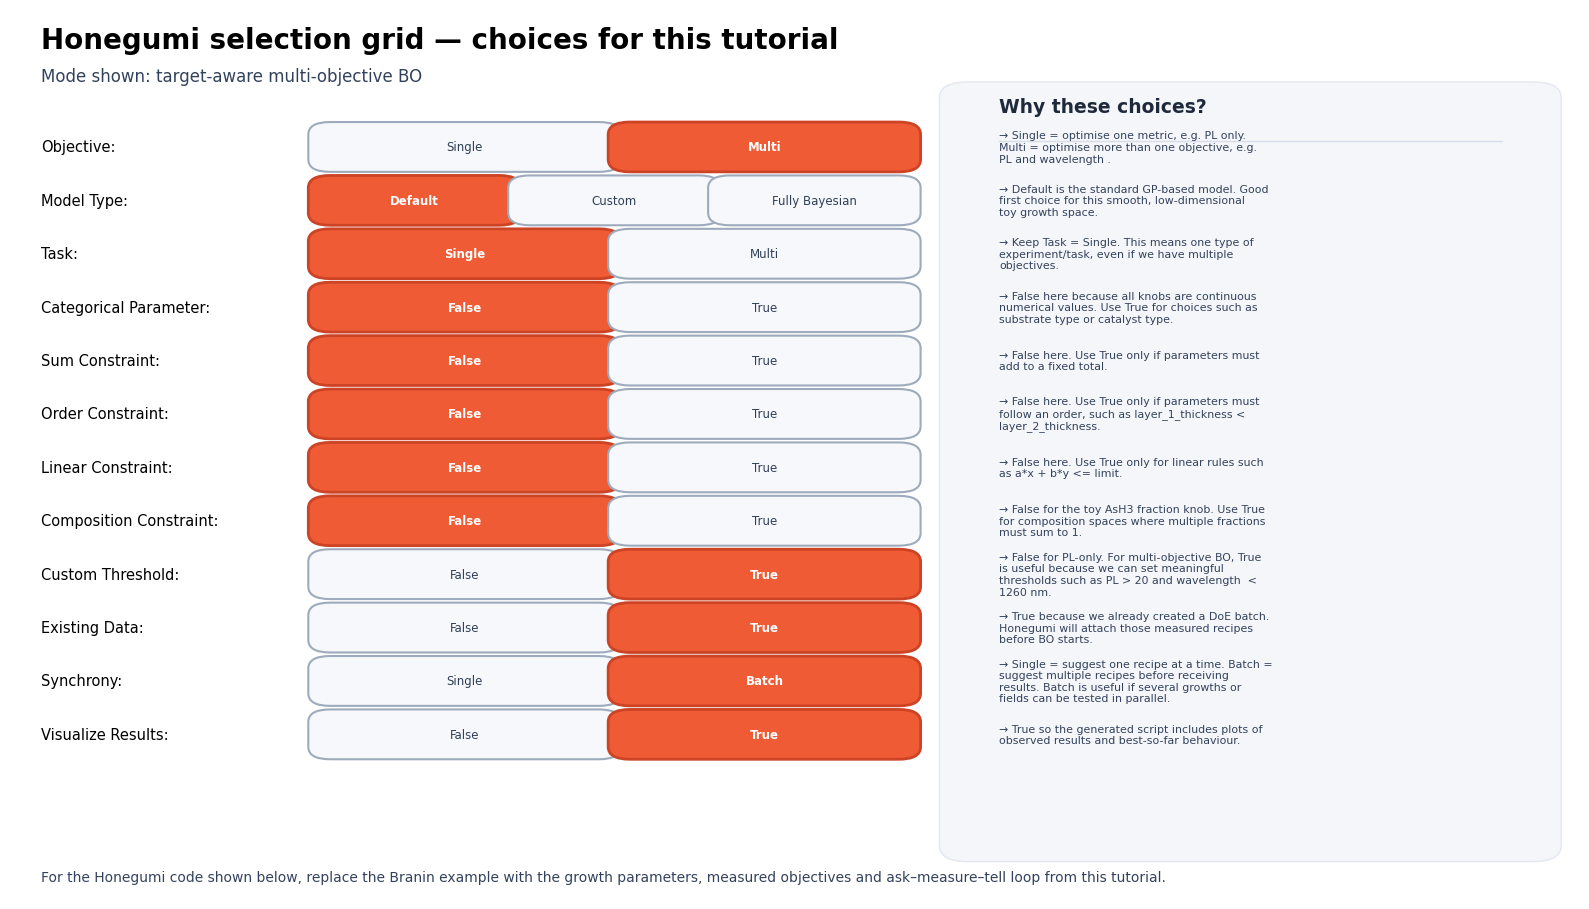

In [ ]:
###@title Honegumi selection grid { display-mode: "form" }

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import textwrap

honegumi_mode = "PL + wavelength multi-objective"  #@param ["PL-only single objective", "PL + wavelength multi-objective"]
synchrony_choice = "Batch"  #@param ["Single", "Batch"]
save_figure = False  #@param {type:"boolean"}

# ── Selection logic for our tutorial ─────────────────────────────────────────
is_multi_objective = honegumi_mode == "PL + wavelength multi-objective"

selected = {
    "Objective": "Multi" if is_multi_objective else "Single",
    "Model Type": "Default",
    "Task": "Single",
    "Categorical Parameter": "False",
    "Sum Constraint": "False",
    "Order Constraint": "False",
    "Linear Constraint": "False",
    "Composition Constraint": "False",
    "Custom Threshold": "True" if is_multi_objective else "False",
    "Existing Data": "True",
    "Synchrony": synchrony_choice,
    "Visualize Results": "True",
}

notes = {
    "Objective": (
        "Single = optimise one metric, e.g. PL only. Multi = optimise more than one "
        "objective, e.g. PL and wavelength ."
    ),
    "Model Type": (
        "Default is the standard GP-based model. Good first choice for this smooth, "
        "low-dimensional toy growth space."
    ),
    "Task": (
        "Keep Task = Single. This means one type of experiment/task, even if we have "
        "multiple objectives."
    ),
    "Categorical Parameter": (
        "False here because all knobs are continuous numerical values. Use True for "
        "choices such as substrate type or catalyst type."
    ),
    "Sum Constraint": (
        "False here. Use True only if parameters must add to a fixed total."
    ),
    "Order Constraint": (
        "False here. Use True only if parameters must follow an order, such as "
        "layer_1_thickness < layer_2_thickness."
    ),
    "Linear Constraint": (
        "False here. Use True only for linear rules such as a*x + b*y <= limit."
    ),
    "Composition Constraint": (
        "False for the toy AsH3 fraction knob. Use True for composition spaces where "
        "multiple fractions must sum to 1."
    ),
    "Custom Threshold": (
        "False for PL-only. For multi-objective BO, True is useful because we can set "
        "meaningful thresholds such as PL > 20 and wavelength  < 1260 nm."
    ),
    "Existing Data": (
        "True because we already created a DoE batch. Honegumi will attach those measured "
        "recipes before BO starts."
    ),
    "Synchrony": (
        "Single = suggest one recipe at a time. Batch = suggest multiple recipes before "
        "receiving results. Batch is useful if several growths or fields can be tested in parallel."
    ),
    "Visualize Results": (
        "True so the generated script includes plots of observed results and best-so-far behaviour."
    ),
}

rows = [
    ("Objective", ["Single", "Multi"]),
    ("Model Type", ["Default", "Custom", "Fully Bayesian"]),
    ("Task", ["Single", "Multi"]),
    ("Categorical Parameter", ["False", "True"]),
    ("Sum Constraint", ["False", "True"]),
    ("Order Constraint", ["False", "True"]),
    ("Linear Constraint", ["False", "True"]),
    ("Composition Constraint", ["False", "True"]),
    ("Custom Threshold", ["False", "True"]),
    ("Existing Data", ["False", "True"]),
    ("Synchrony", ["Single", "Batch"]),
    ("Visualize Results", ["False", "True"]),
]

# ── Styling helpers ──────────────────────────────────────────────────────────
def draw_box(ax, x, y, w, h, text, active=False, fontsize=8.8):
    if active:
        fc = "#ef5b35"
        ec = "#cc4325"
        tc = "white"
        weight = "bold"
        lw = 2.0
    else:
        fc = "#f6f8fb"
        ec = "#9eabbc"
        tc = "#2f3f59"
        weight = "normal"
        lw = 1.5

    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.010,rounding_size=0.014",
        linewidth=lw,
        edgecolor=ec,
        facecolor=fc
    )
    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        color=tc,
        fontweight=weight
    )


def wrap_note(text, width=47):
    return "\n".join(textwrap.wrap(text, width=width))


# ── Figure setup ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 9.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.02,
    0.965,
    "Honegumi selection grid — choices for this tutorial",
    fontsize=20,
    fontweight="bold",
    ha="left",
    va="center"
)

subtitle = (
    "Mode shown: PL-only single-objective BO"
    if not is_multi_objective
    else "Mode shown: target-aware multi-objective BO"
)

ax.text(
    0.02,
    0.925,
    subtitle,
    fontsize=12,
    color="#33425c",
    ha="left",
    va="center"
)

# Right explanation panel
panel_x = 0.61
panel_y = 0.06
panel_w = 0.36
panel_h = 0.84

panel = FancyBboxPatch(
    (panel_x, panel_y), panel_w, panel_h,
    boxstyle="round,pad=0.018,rounding_size=0.018",
    linewidth=1.0,
    edgecolor="#e3e8f0",
    facecolor="#f4f6fa"
)
ax.add_patch(panel)

ax.text(
    panel_x + 0.02,
    0.89,
    "Why these choices?",
    fontsize=13.5,
    fontweight="bold",
    color="#1e293b",
    ha="left",
    va="center"
)

# subtle separator under heading
ax.plot(
    [panel_x + 0.02, panel_x + panel_w - 0.02],
    [0.852, 0.852],
    color="#d6dde8",
    lw=1.0
)

# ── Draw grid ────────────────────────────────────────────────────────────────
y_top = 0.845
row_gap = 0.060
box_h = 0.036

label_x = 0.02
grid_x = 0.20
grid_w = 0.37

for i, (label, options) in enumerate(rows):
    y = y_top - i * row_gap

    # row label
    ax.text(
        label_x,
        y,
        label + ":",
        ha="left",
        va="center",
        fontsize=10.5,
        color="black"
    )

    # option boxes
    n = len(options)
    gap = 0.012
    box_w = (grid_w - gap * (n - 1)) / n

    for j, opt in enumerate(options):
        x = grid_x + j * (box_w + gap)
        draw_box(
            ax,
            x,
            y - box_h / 2,
            box_w,
            box_h,
            opt,
            active=(selected[label] == opt),
            fontsize=8.5
        )

    # right explanation note
    ax.text(
        panel_x + 0.02,
        y,
        "→ " + wrap_note(notes[label], width=47),
        ha="left",
        va="center",
        fontsize=7.9,
        color="#33425c"
    )

# ── Footer message ───────────────────────────────────────────────────────────
footer = (
    "For the Honegumi code shown below, replace the Branin example with the "
    "growth parameters, measured objectives and ask–measure–tell loop from this tutorial."
)

ax.text(
    0.02,
    0.025,
    footer,
    ha="left",
    va="center",
    fontsize=10,
    color="#33425c"
)

plt.tight_layout()

if save_figure:
    fname = "fig_honegumi_selection_grid_updated.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    print(f"Saved as {fname}")

plt.show()


---
### 🎯 Single-objective Bayesian Optimisation

We first use Honegumi for a **single-objective BO problem**.

In the original Honegumi example, `x1`, `x2`, and `branin(...)` are placeholders.  
They represent a simple mathematical test problem used to demonstrate how BO works.

Here, we replace that benchmark problem with a toy epitaxial growth problem.

| Honegumi example | Growth tutorial replacement |
|---|---|
| `x1`, `x2` | `growth_temp`, `v_iii_ratio`, `AsH3_fraction` |
| `branin(...)` | `device_response(...)` |
| minimise objective | maximise PL intensity |
| existing Branin points | initial DoE recipes from `doe_df` |

In this example, BO has one goal:

```text
maximise PL intensity
````

The emission wavelength is still calculated and stored, but it is **not used by the optimiser** in this single-objective example.
This lets us see what happens when we only ask BO to find the brightest recipe.

Because we selected **Synchrony = Batch**, BO can suggest more than one recipe at the same time.
This is useful for experiments where several recipes can be grown or measured together before updating the model.

The plots show:

* how the best PL intensity improves as BO suggests new recipes,
* where the DoE recipes and BO recipes lie in the growth-parameter space.


This single-objective example is useful as a first step, but it only optimises brightness.
In the next section, we extend the same idea to **multi-objective BO**, where we optimise both PL intensity and emission wavelength.


[WARNING 06-28 20:50:31] ax.service.ax_client: Random seed set to 4. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[INFO 06-28 20:50:31] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter growth_temp. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 06-28 20:50:31] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter v_iii_ratio. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 06-28 20:50:31] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for par

Honegumi-style BO adapted for the toy growth problem
─────────────────────────────────────────────────────
Existing DoE recipes = 13
New BO suggestions   = 12
BO batch size        = 2

Objective: maximise PL intensity

Note:
  BO batch 1 means the first group of recipes suggested together.
  BO batch 2 means the next group of recipes suggested together.


[INFO 06-28 20:50:31] ax.core.experiment: Attached custom parameterizations [{'growth_temp': 557.724764, 'v_iii_ratio': 29.338309, 'AsH3_fraction': 0.409876}] as trial 5.
[INFO 06-28 20:50:31] ax.core.experiment: Attached custom parameterizations [{'growth_temp': 521.98343, 'v_iii_ratio': 20.200129, 'AsH3_fraction': 0.478312}] as trial 6.
[INFO 06-28 20:50:31] ax.core.experiment: Attached custom parameterizations [{'growth_temp': 523.4289, 'v_iii_ratio': 16.541955, 'AsH3_fraction': 0.31128}] as trial 7.
[INFO 06-28 20:50:31] ax.core.experiment: Attached custom parameterizations [{'growth_temp': 495.397738, 'v_iii_ratio': 24.060547, 'AsH3_fraction': 0.453839}] as trial 8.
[INFO 06-28 20:50:31] ax.core.experiment: Attached custom parameterizations [{'growth_temp': 498.716417, 'v_iii_ratio': 28.019447, 'AsH3_fraction': 0.246961}] as trial 9.
[INFO 06-28 20:50:31] ax.core.experiment: Attached custom parameterizations [{'growth_temp': 482.941003, 'v_iii_ratio': 47.780562, 'AsH3_fraction': 0


Best recipe predicted by the model:
───────────────────────────────────
growth_temp      = 512.1 °C
v_iii_ratio      = 26.8
AsH3_fraction    = 0.273
Predicted PL     = 40.6 a.u.


,run,phase,bo_batch,growth_temp,v_iii_ratio,AsH3_fraction,pl_intensity,wavelength,best_pl_so_far
0,1,DoE,0,505.0,13.6,0.132,7.5,1230.4,7.5
1,2,DoE,0,547.2,37.5,0.396,1.0,1293.9,7.5
2,3,DoE,0,536.6,35.5,0.258,11.4,1260.4,11.4
3,4,DoE,0,532.0,40.0,0.116,0.7,1234.3,11.4
4,5,DoE,0,551.2,5.7,0.193,2.3,1270.7,11.4
5,6,DoE,0,557.7,29.3,0.410,4.2,1304.9,11.4
6,7,DoE,0,522.0,20.2,0.478,5.2,1298.9,11.4
7,8,DoE,0,523.4,16.5,0.311,24.0,1272.0,24.0
8,9,DoE,0,495.4,24.1,0.454,5.8,1278.2,24.0
9,10,DoE,0,498.7,28.0,0.247,33.0,1240.3,33.0


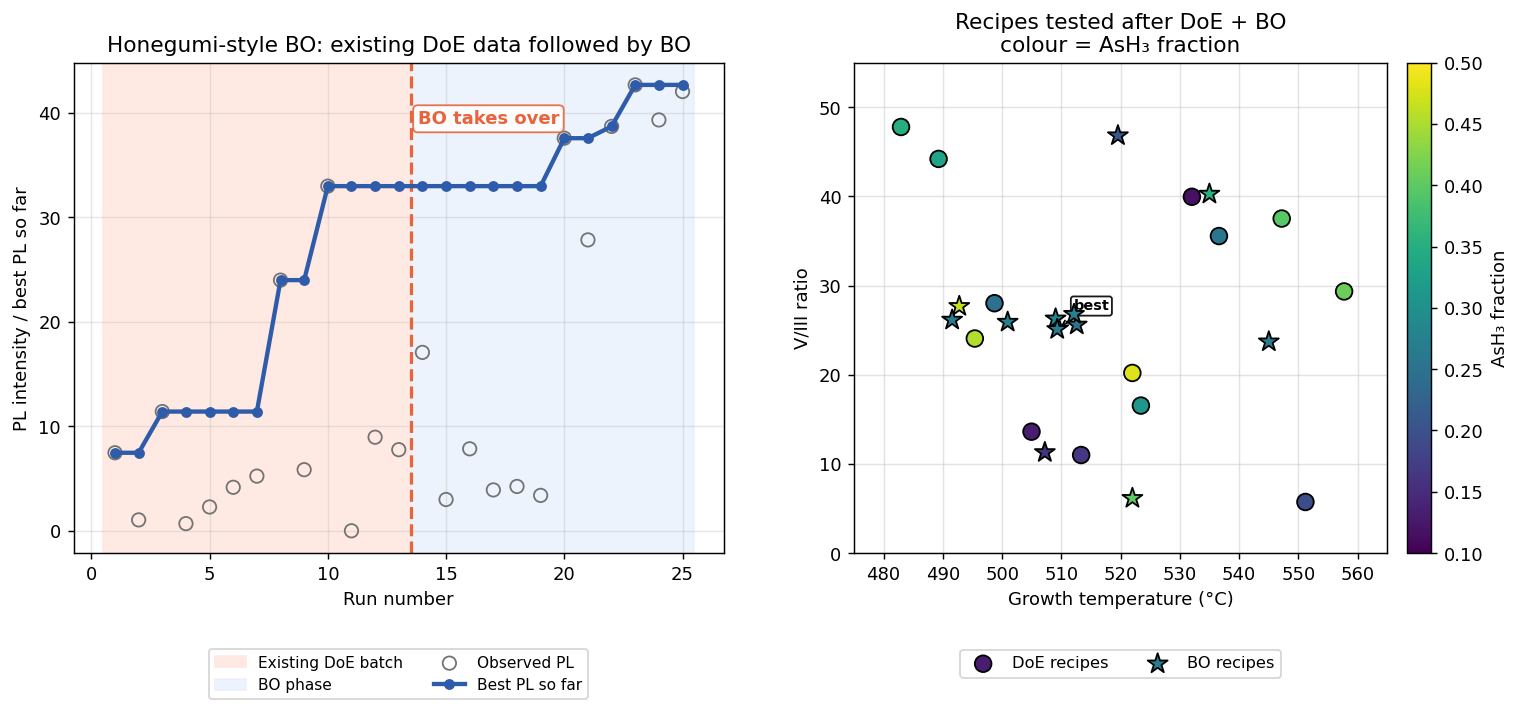

In [ ]:
#@title Honegumi-generated code adapted to our growth problem (Single Objective) { display-mode: "form" }

# Adapted from Honegumi-generated Ax code
# Original Honegumi example used:
#   parameters: x1, x2
#   objective: branin
#   direction: minimize
#
# Here we replace it with:
#   parameters: growth_temp, v_iii_ratio, AsH3_fraction
#   objective: PL intensity
#   direction: maximize

import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ax.service.ax_client import AxClient, ObjectiveProperties

# ── USER CONTROLS ────────────────────────────────────────────────────────────
n_bo_suggestions = 12  #@param {type:"slider", min:4, max:30, step:1}
batch_size       = 2   #@param {type:"slider", min:1, max:4, step:1}
bo_seed          = 4   #@param {type:"integer"}
show_table       = True  #@param {type:"boolean"}


print("Honegumi-style BO adapted for the toy growth problem")
print("─────────────────────────────────────────────────────")
print(f"Existing DoE recipes = {len(doe_df)}")
print(f"New BO suggestions   = {n_bo_suggestions}")
print(f"BO batch size        = {batch_size}")
print()
print("Objective: maximise PL intensity")
print()
print("Note:")
print("  BO batch 1 means the first group of recipes suggested together.")
print("  BO batch 2 means the next group of recipes suggested together.")

# ── REPLACEMENT 1: OBJECTIVE NAME ────────────────────────────────────────────
# Honegumi original:
# obj1_name = "branin"
#
# Our replacement:
obj1_name = "pl_intensity"


# ── REPLACEMENT 2: EXISTING TRAINING DATA ────────────────────────────────────
# Honegumi original:
# X_train = pd.DataFrame([
#     {"x1": -3.0, "x2": 5.0},
#     ...
# ])
#
# Our replacement:
# Use the DoE recipes already generated earlier in the notebook.
X_train = doe_df[
    [
        "growth_temp",
        "v_iii_ratio",
        "AsH3_fraction",
    ]
].copy()

# Honegumi original:
# y_train = [branin(row["x1"], row["x2"]) for _, row in X_train.iterrows()]
#
# Our replacement:
# Use the measured/simulated PL values from the DoE batch.
y_train = doe_df[obj1_name].values

n_train = len(X_train)


# ── CREATE AX CLIENT ─────────────────────────────────────────────────────────
ax_client = AxClient(
    verbose_logging=False,
    random_seed=bo_seed
)


# ── REPLACEMENT 3: SEARCH SPACE AND OBJECTIVE ────────────────────────────────
# Honegumi original:
# parameters=[
#     {"name": "x1", "type": "range", "bounds": [-5.0, 10.0]},
#     {"name": "x2", "type": "range", "bounds": [0.0, 10.0]},
# ]
# objectives={
#     "branin": ObjectiveProperties(minimize=True)
# }
#
# Our replacement:
ax_client.create_experiment(
    name="growth_pl_bo_from_doe",
    parameters=[
        {
            "name": "growth_temp",
            "type": "range",
            "bounds": [480.0, 560.0],
        },
        {
            "name": "v_iii_ratio",
            "type": "range",
            "bounds": [5.0, 50.0],
        },
        {
            "name": "AsH3_fraction",
            "type": "range",
            "bounds": [0.10, 0.50],
        },
    ],
    objectives={
        obj1_name: ObjectiveProperties(minimize=False)
    },
)


# ── ADD EXISTING DoE DATA TO AX ──────────────────────────────────────────────
# This corresponds to Honegumi option:
# Existing Data = True

history = []

for i in range(n_train):
    parameterization = X_train.iloc[i].to_dict()

    # Tell Ax that this recipe was already tested
    _, trial_index = ax_client.attach_trial(parameterization)

    # Give Ax the already-measured PL value
    ax_client.complete_trial(
        trial_index=trial_index,
        raw_data={
            obj1_name: (float(y_train[i]), None)
        }
    )

    # Store for plotting
    history.append({
        "run": i + 1,
        "phase": "DoE",
        "bo_batch": 0,
        "growth_temp": parameterization["growth_temp"],
        "v_iii_ratio": parameterization["v_iii_ratio"],
        "AsH3_fraction": parameterization["AsH3_fraction"],
        "pl_intensity": float(doe_df.iloc[i]["pl_intensity"]),
        "wavelength": float(doe_df.iloc[i]["wavelength"]),
    })


# ── OPTIMISATION LOOP ────────────────────────────────────────────────────────
rng_bo = np.random.RandomState(bo_seed)

suggestions_done = 0
bo_batch_id = 0

while suggestions_done < n_bo_suggestions:

    bo_batch_id += 1

    current_batch_size = min(
        batch_size,
        n_bo_suggestions - suggestions_done
    )

    # Honegumi uses get_next_trials(...) for batch optimisation
    parameterizations, optimization_complete = ax_client.get_next_trials(
        current_batch_size
    )

    for trial_index, parameterization in list(parameterizations.items()):

        # Extract suggested parameters
        growth_temp = parameterization["growth_temp"]
        v_iii_ratio = parameterization["v_iii_ratio"]
        AsH3_fraction = parameterization["AsH3_fraction"]

        # ── REPLACEMENT 4: MEASUREMENT STEP ─────────────────────────────────
        # Honegumi original:
        # results = branin(x1, x2)
        #
        # Toy notebook replacement:
        measured_pl, measured_wavelength = device_response(
            growth_temp,
            v_iii_ratio,
            AsH3_fraction,
            rng=rng_bo
        )

        # Real experiment replacement would be something like:
        # measured_pl, measured_wavelength = run_growth_measurement_and_analysis(parameterization)

        # Report measured result back to BO
        ax_client.complete_trial(
            trial_index=trial_index,
            raw_data={
                obj1_name: (float(measured_pl), None)
            }
        )

        suggestions_done += 1

        # Store for plotting
        history.append({
            "run": n_train + suggestions_done,
            "phase": "BO",
            "bo_batch": bo_batch_id,
            "growth_temp": growth_temp,
            "v_iii_ratio": v_iii_ratio,
            "AsH3_fraction": AsH3_fraction,
            "pl_intensity": float(measured_pl),
            "wavelength": float(measured_wavelength),
        })


# ── BEST PARAMETERS ──────────────────────────────────────────────────────────
best_parameters, metrics = ax_client.get_best_parameters()

print("\nBest recipe predicted by the model:")
print("───────────────────────────────────")
for k, v in best_parameters.items():
    if k == "growth_temp":
        print(f"{k:16s} = {v:.1f} °C")
    elif k == "AsH3_fraction":
        print(f"{k:16s} = {v:.3f}")
    else:
        print(f"{k:16s} = {v:.1f}")

try:
    predicted_pl = metrics[0][obj1_name]
except Exception:
    predicted_pl = metrics[obj1_name]

print(f"{'Predicted PL':16s} = {predicted_pl:.1f} a.u.")


# ── COLLECT RESULTS ──────────────────────────────────────────────────────────
history_df = pd.DataFrame(history)
history_df = history_df.sort_values("run").reset_index(drop=True)
history_df["best_pl_so_far"] = history_df["pl_intensity"].cummax()

best_measured_idx = history_df["pl_intensity"].idxmax()
best_measured = history_df.loc[best_measured_idx]

if show_table:
    display(
        history_df.round({
            "growth_temp": 1,
            "v_iii_ratio": 1,
            "AsH3_fraction": 3,
            "pl_intensity": 1,
            "wavelength": 1,
            "best_pl_so_far": 1,
        })
    )


# ── PLOT RESULTS ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14.2, 4.9), dpi=130)
ax1, ax2 = axes

# ══════════════════════════════════════════════════════════════════════════════
# Plot 1: PL over runs
# ══════════════════════════════════════════════════════════════════════════════

# Shade DoE region
ax1.axvspan(
    0.5,
    n_train + 0.5,
    color="#ffe7df",
    alpha=0.85,
    label="Existing DoE batch"
)

# Shade BO region
ax1.axvspan(
    n_train + 0.5,
    len(history_df) + 0.5,
    color="#e8f0fc",
    alpha=0.75,
    label="BO phase"
)

# Observed PL values
ax1.scatter(
    history_df["run"],
    history_df["pl_intensity"],
    facecolors="none",
    edgecolors="0.45",
    s=55,
    label="Observed PL",
    zorder=3
)

# Best PL so far
ax1.plot(
    history_df["run"],
    history_df["best_pl_so_far"],
    "-o",
    color="#2E5BAA",
    lw=2.4,
    ms=5,
    label="Best PL so far",
    zorder=4
)

# BO handoff line
ax1.axvline(
    n_train + 0.5,
    color="#E8643C",
    lw=1.8,
    ls="--"
)

ax1.text(
    n_train + 0.8,
    0.88 * ax1.get_ylim()[1],
    "BO takes over",
    fontsize=10,
    color="#E8643C",
    fontweight="bold",
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.25",
        fc="white",
        ec="#E8643C",
        alpha=0.9
    )
)

ax1.set_xlabel("Run number")
ax1.set_ylabel("PL intensity / best PL so far")
ax1.set_title("Honegumi-style BO: existing DoE data followed by BO")
ax1.grid(True, alpha=0.3)

ax1.legend(
    fontsize=8.5,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True
)


# ══════════════════════════════════════════════════════════════════════════════
# Plot 2: recipe space after DoE + BO
# ══════════════════════════════════════════════════════════════════════════════

doe_part = history_df[history_df["phase"] == "DoE"]
bo_part = history_df[history_df["phase"] == "BO"]

# DoE points
sc = ax2.scatter(
    doe_part["growth_temp"],
    doe_part["v_iii_ratio"],
    c=doe_part["AsH3_fraction"],
    cmap="viridis",
    vmin=0.10,
    vmax=0.50,
    s=85,
    edgecolor="black",
    marker="o",
    label="DoE recipes",
    zorder=3
)

# All BO points together — no batch labels
ax2.scatter(
    bo_part["growth_temp"],
    bo_part["v_iii_ratio"],
    c=bo_part["AsH3_fraction"],
    cmap="viridis",
    vmin=0.10,
    vmax=0.50,
    s=135,
    edgecolor="black",
    marker="*",
    label="BO recipes",
    zorder=4
)

# Label only best measured recipe
ax2.annotate(
    "best",
    xy=(best_measured["growth_temp"], best_measured["v_iii_ratio"]),
    xytext=(9, 9),
    textcoords="offset points",
    fontsize=8,
    fontweight="bold",
    color="black",
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.18",
        fc="white",
        ec="black",
        alpha=0.9
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=1
    )
)

ax2.set_xlabel("Growth temperature (°C)")
ax2.set_ylabel("V/III ratio")
ax2.set_title("Recipes tested after DoE + BO\ncolour = AsH₃ fraction")
ax2.set_xlim(475, 565)
ax2.set_ylim(0, 55)
ax2.grid(True, alpha=0.35)

# Simple legend outside second plot
ax2.legend(
    fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True
)

# Colourbar
cbar = fig.colorbar(sc, ax=ax2, pad=0.03)
cbar.set_label("AsH₃ fraction")

---
### 🎯🎯 Multiobjective Optimisation

The PL-only optimiser can find a bright recipe, but brightness alone is not the full goal.

For this toy communication-wavelength problem, we want:

- **high PL intensity**
- **emission wavelength ≥1260 nm**


#### What does the Pareto front show?

When we optimise more than one objective, there is often no single best recipe.

Here we want two things at the same time:

- **high PL intensity**
- **longer emission wavelength**, ideally reaching **λ ≥1260 nm**

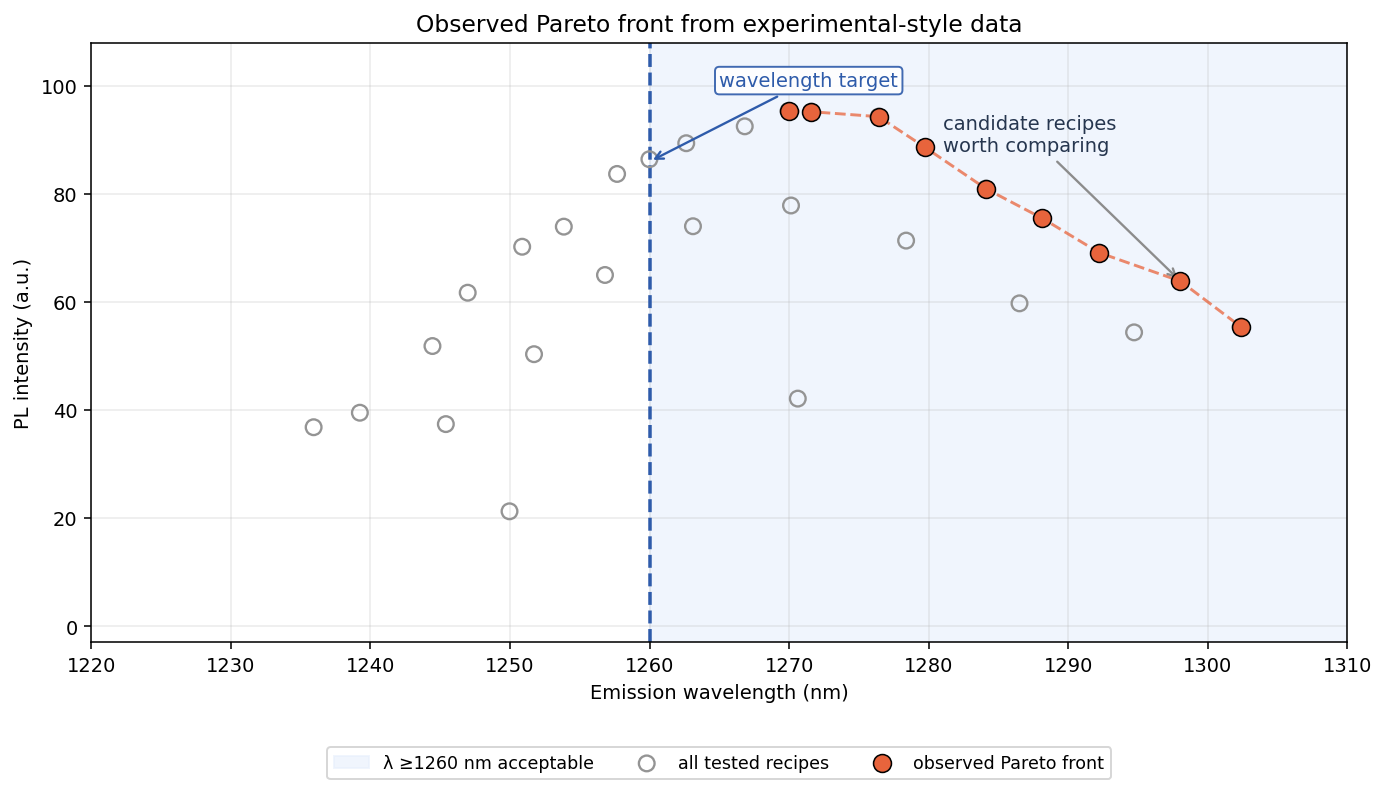

In [ ]:
#@title  Pareto Front example{ display-mode: "form" }

import numpy as np
import matplotlib.pyplot as plt

target = 1260

# -------------------------------------------------------------------------
# Illustrative experimental-style data
# -------------------------------------------------------------------------
# These are synthetic points, not real BO output.
# Objective idea for this diagram:
#   maximise PL intensity
#   maximise emission wavelength
#
# Pareto front = recipes where no other tested recipe has both:
#   higher/equal PL and higher/equal wavelength.

wl_all = np.array([
    1250, 1236, 1270, 1240, 1244, 1248, 1251, 1254,
    1257, 1260, 1263, 1266, 1269, 1272, 1276, 1280,
    1284, 1288, 1293, 1298, 1303,
    1246, 1252, 1258, 1264, 1270, 1278, 1286, 1295
], dtype=float)

pl_all = np.array([
    20, 34, 40, 42, 55, 61, 68, 74,
    82, 86, 89, 92, 95, 96, 91, 87,
    82, 76, 71, 63, 58,
    38, 49, 64, 73, 80, 70, 60, 52
], dtype=float)

# Add small measurement-like scatter
rng = np.random.RandomState(21)
wl_all = wl_all + rng.normal(0, 0.6, size=len(wl_all))
pl_all = pl_all + rng.normal(0, 1.8, size=len(pl_all))

# -------------------------------------------------------------------------
# Calculate observed Pareto front for max wavelength and max PL
# -------------------------------------------------------------------------
def pareto_max_max(x, y):
    """
    Return mask for observed Pareto points when both x and y are maximised.
    A point is dominated if another point has >= x and >= y,
    with at least one strictly better.
    """
    n = len(x)
    keep = np.ones(n, dtype=bool)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            better_or_equal = (x[j] >= x[i]) and (y[j] >= y[i])
            strictly_better = (x[j] > x[i]) or (y[j] > y[i])

            if better_or_equal and strictly_better:
                keep[i] = False
                break

    return keep


pareto_mask = pareto_max_max(wl_all, pl_all)

pareto_wl = wl_all[pareto_mask]
pareto_pl = pl_all[pareto_mask]

# Sort for plotting the observed front
order = np.argsort(pareto_wl)
pareto_wl = pareto_wl[order]
pareto_pl = pareto_pl[order]

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5.8), dpi=140)

# Acceptable wavelength region
ax.axvspan(
    target,
    1310,
    color="#e8f0fc",
    alpha=0.65,
    label="λ ≥1260 nm acceptable"
)

# Target line
ax.axvline(
    target,
    color="#2E5BAA",
    linestyle="--",
    lw=1.8
)

# All tested recipes
ax.scatter(
    wl_all,
    pl_all,
    facecolors="none",
    edgecolors="0.58",
    s=65,
    linewidth=1.2,
    label="all tested recipes",
    zorder=2
)

# Observed Pareto front: points + light guide line, not a smooth curve
ax.plot(
    pareto_wl,
    pareto_pl,
    "--",
    color="#E8643C",
    lw=1.5,
    alpha=0.75,
    zorder=3
)

ax.scatter(
    pareto_wl,
    pareto_pl,
    color="#E8643C",
    edgecolor="black",
    s=85,
    linewidth=0.8,
    label="observed Pareto front",
    zorder=4
)

# Minimal annotations
ax.annotate(
    "wavelength target",
    xy=(target, 86),
    xytext=(1265, 101),
    fontsize=10,
    color="#2E5BAA",
    ha="left",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        color="#2E5BAA",
        lw=1.2
    ),
    bbox=dict(
        boxstyle="round,pad=0.22",
        fc="white",
        ec="#2E5BAA",
        alpha=0.9
    )
)

ax.annotate(
    "candidate recipes\nworth comparing",
    xy=(pareto_wl[-2], pareto_pl[-2]),
    xytext=(1281, 91),
    fontsize=10,
    color="#26364f",
    ha="left",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        color="0.55",
        lw=1.2
    )
)

ax.set_xlabel("Emission wavelength (nm)")
ax.set_ylabel("PL intensity (a.u.)")
ax.set_title("Observed Pareto front from experimental-style data")

ax.set_xlim(1220, 1310)
ax.set_ylim(-3, 108)
ax.grid(True, alpha=0.25)

# Legend outside plot
ax.legend(
    fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=3,
    frameon=True
)

plt.tight_layout()
plt.show()


The orange points show the **observed Pareto front**. These are recipes where no other tested recipe is clearly better after considering the direction of each objective.

In this example, both objectives are written as **maximisation** objectives:

```text
maximise PL intensity
maximise emission wavelength
````

So a recipe is only dominated if another tested recipe has both **higher PL** and **longer wavelength**.

This is important because, in multi-objective optimisation, the objectives can sometimes **conflict**. Improving one objective may make another objective worse.

For example:

* one recipe may have **higher PL** but a **shorter wavelength**,
* another recipe may reach a **longer wavelength** but have **lower PL**.

That is the trade-off.

The shape and position of the Pareto front depend on how the objectives are defined.
For example, in another problem we might want to:

```text
maximise PL intensity
minimise threshold
```

or:

```text
maximise yield
minimise wavelength variation
```

In those cases, the Pareto front would be calculated differently because “better” points lie in a different direction.

The Pareto front is useful because it does not force one answer immediately.
Instead, it gives a set of strong candidate recipes where each point represents a different compromise between the objectives.

The experimentalist can then choose which compromise is most suitable for the next growth or device target.





[WARNING 06-28 21:37:58] ax.service.ax_client: Random seed set to 6. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[INFO 06-28 21:37:58] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter growth_temp. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 06-28 21:37:58] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter v_iii_ratio. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 06-28 21:37:58] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for par

Honegumi-style multi-objective BO adapted for the toy growth problem
────────────────────────────────────────────────────────────────────
Existing DoE recipes = 13
New BO suggestions   = 11
BO batch size        = 3

Objective 1: maximise PL intensity
Objective 2: maximise emission wavelength
Useful wavelength target: λ ≥ 1260 nm

Selected practical recipe:
──────────────────────────
Run number        = 22
Phase             = BO
T                 = 521.8 °C
V/III             = 21.7
AsH3 fraction     = 0.289
PL intensity      = 79.9 a.u.
Emission λ        = 1264.3 nm
Target check      = ✅ λ ≥ 1260 nm


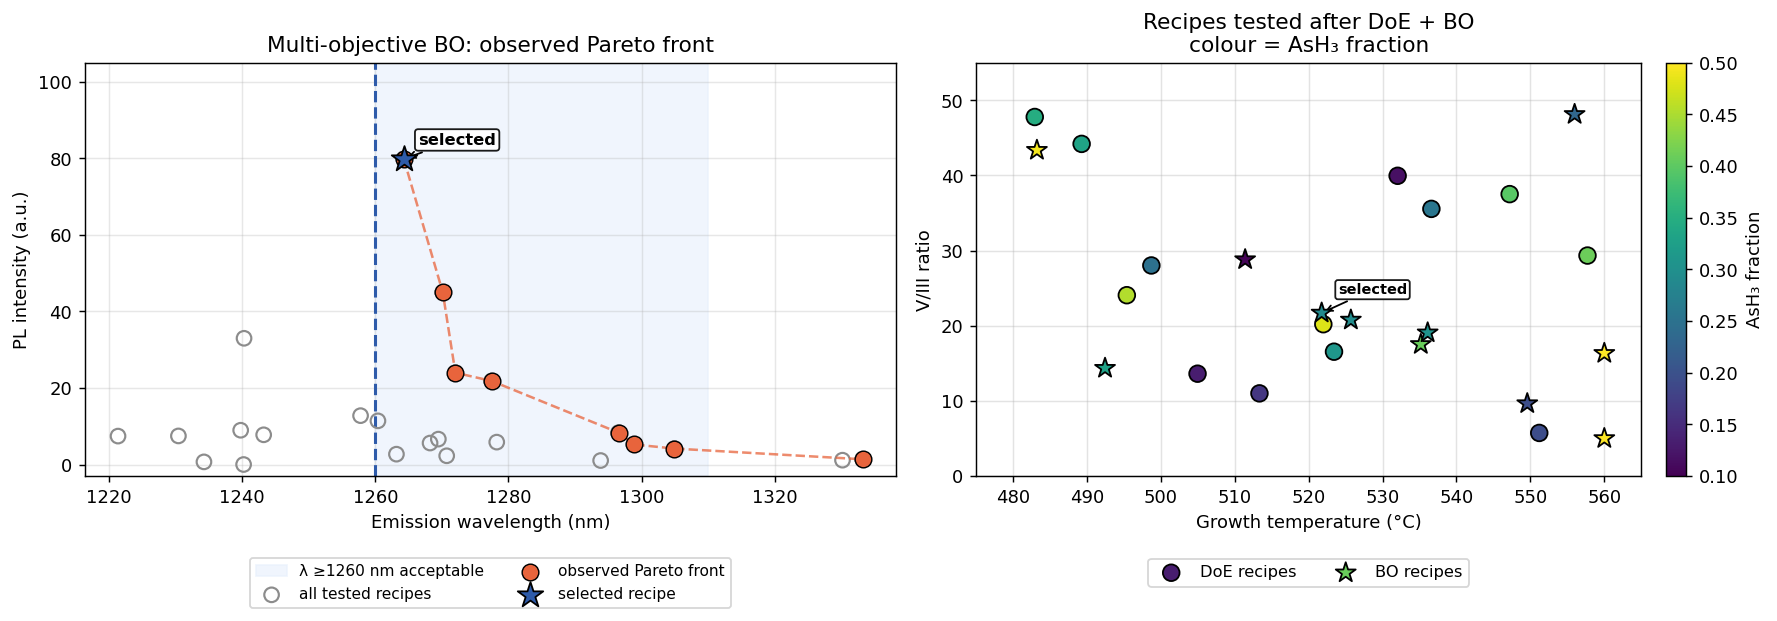

In [ ]:
#@title Honegumi-generated multi-objective optimisation adapted to our growth problem { display-mode: "form" }

# Adapted from Honegumi-generated multi-objective Ax code
# Original Honegumi example used:
#   parameters: x1, x2
#   objectives: branin, branin_swapped
#   direction: minimize both
#
# Here we replace it with:
#   parameters: growth_temp, v_iii_ratio, AsH3_fraction
#   objectives: PL intensity and emission wavelength
#   direction: maximize both

import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ax.service.ax_client import AxClient, ObjectiveProperties

# ── USER CONTROLS ────────────────────────────────────────────────────────────
n_bo_suggestions = 11  #@param {type:"slider", min:6, max:40, step:1}
batch_size       = 3   #@param {type:"slider", min:1, max:4, step:1}
bo_seed          = 6   #@param {type:"integer"}
show_table       = True  #@param {type:"boolean"}

target_wavelength = 1260

print("Honegumi-style multi-objective BO adapted for the toy growth problem")
print("────────────────────────────────────────────────────────────────────")
print(f"Existing DoE recipes = {len(doe_df)}")
print(f"New BO suggestions   = {n_bo_suggestions}")
print(f"BO batch size        = {batch_size}")
print()
print("Objective 1: maximise PL intensity")
print("Objective 2: maximise emission wavelength")
print(f"Useful wavelength target: λ ≥ {target_wavelength} nm")

# ── REPLACEMENT 1: OBJECTIVE NAMES ───────────────────────────────────────────
# Honegumi original:
# obj1_name = "branin"
# obj2_name = "branin_swapped"
#
# Our replacement:
obj1_name = "pl_intensity"
obj2_name = "wavelength"


# ── REPLACEMENT 2: EXISTING TRAINING DATA FROM DoE ───────────────────────────
# Honegumi original:
# X_train = pd.DataFrame([{"x1": ..., "x2": ...}, ...])
#
# Our replacement:
X_train = doe_df[
    [
        "growth_temp",
        "v_iii_ratio",
        "AsH3_fraction",
    ]
].copy()

# Honegumi original calculates y_train from branin_moo(...)
#
# Our replacement:
# Use the already measured/simulated DoE outputs.
y_train = [
    {
        obj1_name: float(row["pl_intensity"]),
        obj2_name: float(row["wavelength"]),
    }
    for _, row in doe_df.iterrows()
]

n_train = len(X_train)


# ── CREATE AX CLIENT ─────────────────────────────────────────────────────────
ax_client = AxClient(
    verbose_logging=False,
    random_seed=bo_seed
)


# ── REPLACEMENT 3: SEARCH SPACE AND OBJECTIVES ───────────────────────────────
# Honegumi original:
# parameters=[
#     {"name": "x1", "type": "range", "bounds": [-5.0, 10.0]},
#     {"name": "x2", "type": "range", "bounds": [0.0, 10.0]},
# ]
# objectives={
#     "branin": ObjectiveProperties(minimize=True, threshold=25.0),
#     "branin_swapped": ObjectiveProperties(minimize=True, threshold=15.0),
# }
#
# Our replacement:
ax_client.create_experiment(
    name="growth_pl_wavelength_multiobjective_bo",
    parameters=[
        {
            "name": "growth_temp",
            "type": "range",
            "bounds": [480.0, 560.0],
        },
        {
            "name": "v_iii_ratio",
            "type": "range",
            "bounds": [5.0, 50.0],
        },
        {
            "name": "AsH3_fraction",
            "type": "range",
            "bounds": [0.10, 0.50],
        },
    ],
    objectives={
        obj1_name: ObjectiveProperties(
            minimize=False,
            threshold=20.0
        ),
        obj2_name: ObjectiveProperties(
            minimize=False,
            threshold=float(target_wavelength)
        ),
    },
)


# ── ADD EXISTING DoE DATA TO AX ──────────────────────────────────────────────
# This corresponds to Honegumi option:
# Existing Data = True

history = []

for i in range(n_train):
    parameterization = X_train.iloc[i].to_dict()

    # Tell Ax that this recipe was already tested
    _, trial_index = ax_client.attach_trial(parameterization)

    # Give Ax the already measured PL and wavelength
    ax_client.complete_trial(
        trial_index=trial_index,
        raw_data={
            obj1_name: (y_train[i][obj1_name], None),
            obj2_name: (y_train[i][obj2_name], None),
        }
    )

    history.append({
        "run": i + 1,
        "phase": "DoE",
        "growth_temp": parameterization["growth_temp"],
        "v_iii_ratio": parameterization["v_iii_ratio"],
        "AsH3_fraction": parameterization["AsH3_fraction"],
        "pl_intensity": y_train[i][obj1_name],
        "wavelength": y_train[i][obj2_name],
    })


# ── OPTIMISATION LOOP ────────────────────────────────────────────────────────
rng_bo = np.random.RandomState(bo_seed)

suggestions_done = 0
bo_batch_id = 0

while suggestions_done < n_bo_suggestions:

    bo_batch_id += 1

    current_batch_size = min(
        batch_size,
        n_bo_suggestions - suggestions_done
    )

    # Honegumi uses get_next_trials(...) for batch optimisation
    parameterizations, optimization_complete = ax_client.get_next_trials(
        current_batch_size
    )

    for trial_index, parameterization in list(parameterizations.items()):

        # Extract suggested parameters
        growth_temp = parameterization["growth_temp"]
        v_iii_ratio = parameterization["v_iii_ratio"]
        AsH3_fraction = parameterization["AsH3_fraction"]

        # ── REPLACEMENT 4: MEASUREMENT STEP ─────────────────────────────────
        # Honegumi original:
        # results = branin_moo(x1, x2)
        #
        # Toy notebook replacement:
        measured_pl, measured_wavelength = device_response(
            growth_temp,
            v_iii_ratio,
            AsH3_fraction,
            rng=rng_bo
        )

        # Real experiment replacement would be something like:
        # measured_pl, measured_wavelength = run_growth_measurement_and_analysis(parameterization)

        # Report measured objectives back to BO
        ax_client.complete_trial(
            trial_index=trial_index,
            raw_data={
                obj1_name: (float(measured_pl), None),
                obj2_name: (float(measured_wavelength), None),
            }
        )

        suggestions_done += 1

        history.append({
            "run": n_train + suggestions_done,
            "phase": "BO",
            "bo_batch": bo_batch_id,
            "growth_temp": growth_temp,
            "v_iii_ratio": v_iii_ratio,
            "AsH3_fraction": AsH3_fraction,
            "pl_intensity": float(measured_pl),
            "wavelength": float(measured_wavelength),
        })


# ── COLLECT RESULTS ──────────────────────────────────────────────────────────
history_df = pd.DataFrame(history)
history_df = history_df.sort_values("run").reset_index(drop=True)

if show_table:
    display(
        history_df.round({
            "growth_temp": 1,
            "v_iii_ratio": 1,
            "AsH3_fraction": 3,
            "pl_intensity": 1,
            "wavelength": 1,
        })
    )


# ── OBSERVED PARETO FRONT: MAX PL AND MAX WAVELENGTH ─────────────────────────
def pareto_max_max(df, x_col, y_col):
    """
    Observed Pareto front for maximising both x_col and y_col.

    A point is dominated if another tested point has:
      x >= current x and y >= current y,
    with at least one strictly better.
    """
    x = df[x_col].values
    y = df[y_col].values

    keep = np.ones(len(df), dtype=bool)

    for i in range(len(df)):
        for j in range(len(df)):
            if i == j:
                continue

            better_or_equal = (x[j] >= x[i]) and (y[j] >= y[i])
            strictly_better = (x[j] > x[i]) or (y[j] > y[i])

            if better_or_equal and strictly_better:
                keep[i] = False
                break

    return keep


pareto_mask = pareto_max_max(
    history_df,
    x_col="wavelength",
    y_col="pl_intensity"
)

pareto_df = history_df[pareto_mask].copy()
pareto_df = pareto_df.sort_values("wavelength")


# ── CHOOSE A PRACTICAL RECIPE FOR REPORTING ──────────────────────────────────
# If possible, choose the highest-PL recipe that already satisfies λ ≥1260 nm.
feasible_df = history_df[history_df["wavelength"] >= target_wavelength]

if len(feasible_df) > 0:
    selected_idx = feasible_df["pl_intensity"].idxmax()
else:
    selected_idx = history_df["pl_intensity"].idxmax()

selected_recipe = history_df.loc[selected_idx]

print("\nSelected practical recipe:")
print("──────────────────────────")
print(f"Run number        = {int(selected_recipe['run'])}")
print(f"Phase             = {selected_recipe['phase']}")
print(f"T                 = {selected_recipe['growth_temp']:.1f} °C")
print(f"V/III             = {selected_recipe['v_iii_ratio']:.1f}")
print(f"AsH3 fraction     = {selected_recipe['AsH3_fraction']:.3f}")
print(f"PL intensity      = {selected_recipe['pl_intensity']:.1f} a.u.")
print(f"Emission λ        = {selected_recipe['wavelength']:.1f} nm")

if selected_recipe["wavelength"] >= target_wavelength:
    print(f"Target check      = ✅ λ ≥ {target_wavelength} nm")
else:
    print(f"Target check      = ⚠️ below {target_wavelength} nm")


# ── PLOT RESULTS ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.0), dpi=130)
ax1, ax2 = axes

# ══════════════════════════════════════════════════════════════════════════════
# Plot 1: objective space and observed Pareto front
# ══════════════════════════════════════════════════════════════════════════════

# Acceptable wavelength region
ax1.axvspan(
    target_wavelength,
    1310,
    color="#e8f0fc",
    alpha=0.65,
    label="λ ≥1260 nm acceptable"
)

ax1.axvline(
    target_wavelength,
    color="#2E5BAA",
    linestyle="--",
    lw=1.7
)

# All recipes
ax1.scatter(
    history_df["wavelength"],
    history_df["pl_intensity"],
    facecolors="none",
    edgecolors="0.55",
    s=65,
    linewidth=1.2,
    label="all tested recipes",
    zorder=2
)

# Observed Pareto front
ax1.plot(
    pareto_df["wavelength"],
    pareto_df["pl_intensity"],
    "--",
    color="#E8643C",
    lw=1.4,
    alpha=0.75,
    zorder=3
)

ax1.scatter(
    pareto_df["wavelength"],
    pareto_df["pl_intensity"],
    color="#E8643C",
    edgecolor="black",
    s=85,
    linewidth=0.8,
    label="observed Pareto front",
    zorder=4
)

# Selected practical recipe
ax1.scatter(
    selected_recipe["wavelength"],
    selected_recipe["pl_intensity"],
    marker="*",
    s=220,
    color="#2E5BAA",
    edgecolor="black",
    label="selected recipe",
    zorder=5
)

ax1.annotate(
    "selected",
    xy=(selected_recipe["wavelength"], selected_recipe["pl_intensity"]),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=9,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.2",
        fc="white",
        ec="black",
        alpha=0.9
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=1
    )
)

ax1.set_xlabel("Emission wavelength (nm)")
ax1.set_ylabel("PL intensity (a.u.)")
ax1.set_title("Multi-objective BO: observed Pareto front")
ax1.grid(True, alpha=0.3)

x_min = min(history_df["wavelength"].min(), target_wavelength) - 5
x_max = max(history_df["wavelength"].max(), target_wavelength) + 5
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(-3, max(105, history_df["pl_intensity"].max() + 8))

ax1.legend(
    fontsize=8.5,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True
)


# ══════════════════════════════════════════════════════════════════════════════
# Plot 2: recipe space
# ══════════════════════════════════════════════════════════════════════════════

doe_part = history_df[history_df["phase"] == "DoE"]
bo_part = history_df[history_df["phase"] == "BO"]

# DoE recipes
sc = ax2.scatter(
    doe_part["growth_temp"],
    doe_part["v_iii_ratio"],
    c=doe_part["AsH3_fraction"],
    cmap="viridis",
    vmin=0.10,
    vmax=0.50,
    s=85,
    edgecolor="black",
    marker="o",
    label="DoE recipes",
    zorder=3
)

# BO recipes
ax2.scatter(
    bo_part["growth_temp"],
    bo_part["v_iii_ratio"],
    c=bo_part["AsH3_fraction"],
    cmap="viridis",
    vmin=0.10,
    vmax=0.50,
    s=135,
    edgecolor="black",
    marker="*",
    label="BO recipes",
    zorder=4
)

# Selected recipe label
ax2.annotate(
    "selected",
    xy=(selected_recipe["growth_temp"], selected_recipe["v_iii_ratio"]),
    xytext=(9, 9),
    textcoords="offset points",
    fontsize=8,
    fontweight="bold",
    color="black",
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.18",
        fc="white",
        ec="black",
        alpha=0.9
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=1
    )
)

ax2.set_xlabel("Growth temperature (°C)")
ax2.set_ylabel("V/III ratio")
ax2.set_title("Recipes tested after DoE + BO\ncolour = AsH₃ fraction")
ax2.set_xlim(475, 565)
ax2.set_ylim(0, 55)
ax2.grid(True, alpha=0.35)

ax2.legend(
    fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True
)

cbar = fig.colorbar(sc, ax=ax2, pad=0.03)
cbar.set_label("AsH₃ fraction")

plt.tight_layout()
plt.show()


> 💬 **Try it**
>
> In one run, BO may find a recipe that reaches the wavelength target, but the PL may still be too low.  
> For example, you might find:
>
> ```text
> PL intensity ≈55 a.u.
> emission wavelength ≥1260 nm
> ```
>
> That satisfies the wavelength target, but not the PL target.
>
> Now try to find a recipe with:
>
> ```text
> PL intensity ≥50 a.u.
> emission wavelength ≥1270 nm
> ```
>
> **Hints:**
>
> - Increase `n_bo_suggestions` from 16 to 30 or 40.  
>   More BO suggestions usually give the optimiser more chance to explore the useful region.
>
> - Try changing `bo_seed` to 1, 2, 3, 4, or 5.  
>   Different seeds can lead BO to explore slightly different candidate recipes.
>
> - Try `batch_size = 1`.  
>   This is sequential BO: the model updates after every new recipe. It is often more efficient when the total number of trials is limited.
>
> - Then compare with `batch_size = 2` or `batch_size = 4`.  
>   Larger batches are useful experimentally because several recipes can be tested together, but they may be less efficient because BO has to suggest multiple recipes before seeing the new results.
>
> **Questions to think about:**
>
> - Does the observed Pareto front become clearer as `n_bo_suggestions` increases?
> - Does BO find a similar high-PL, long-wavelength region for different `bo_seed` values?
> - Among the recipes that satisfy `λ ≥1260 nm`, which one gives the highest PL?
> - Which recipe would you choose for the next experiment, and why?




---
## 🔬 Section 5 · From the toy notebook to the real device pipeline

The examples above are a **conceptual miniature** of the workflow used in our real microring optimisation study.

**Companion repository:**  
🔗 [github.com/OMS-lab/Microring_MOBO](https://github.com/OMS-lab/Microring_MOBO)

This repository contains a multi-objective Bayesian optimisation workflow for bottom-up grown **InP/InAsP multi-quantum-well microring lasers**, where the optimisation targets include emission wavelength, lasing threshold, and device yield.

*(Athavale et al., ACS Photonics)*

| This tutorial notebook | Real `Microring_MOBO` pipeline |
|---|---|
| Toy epitaxial-growth simulator | Measured InP/InAsP MQW microring device data |
| 3 simplified growth knobs | MOCVD growth + ring-geometry parameters |
| Initial Latin-Hypercube DoE | PCA-enhanced DoE + Latin-Hypercube sampling for broader exploration |
| Honegumi/Ax template | BoTorch-based multi-objective BO workflow |
| PL intensity + emission wavelength | Lasing threshold + emission wavelength + yield |
| Fast simulated measurements | Experimental μ-PL measurements and extracted device metrics |

The key idea is the same:

```text
choose recipe → measure device response → update BO model → suggest next recipe
````

In the toy notebook, `device_response(...)` gives an instant simulated measurement.
In the real pipeline, this step is replaced by measured spectra, threshold extraction, wavelength extraction, and yield calculation.

To try the real workflow, clone the repository and start from:

```text
BO with DoE.ipynb
```

Then replace the example dataset, parameter bounds, and objectives with your own experimental data.





---
### ⚙️ Under the hood — BoTorch

Ax and Honegumi make Bayesian optimisation easier to use, but underneath they rely on **BoTorch**.

This section shows the same idea more explicitly.

There are two main steps:

1. **Fit a Gaussian process** to the recipes measured so far.
2. **Maximise an acquisition function** to suggest the next recipe.

We first show a **single-objective** loop using `qLogExpectedImprovement`, where the only goal is:

```text
maximise PL intensity
````

Then we show one **multi-objective** step using a ParEGO-style acquisition, where the objectives are:

```text
maximise PL intensity
maximise emission wavelength
```

This is similar in spirit to the acquisition strategy used in the real microring BO workflow.

> You do not need to understand every line of code.
>
> The important pattern is:
>
> ```text
> fit GP → maximise acquisition → suggest recipe → observe result → repeat
> ```

▶ **Run the cell below** to see one BoTorch loop written out directly.



BoTorch single-objective loop
────────────────────────────
Acquisition function: qLogExpectedImprovement
Objective: maximise PL intensity

Best recipe found by single-objective BoTorch:
────────────────────────────────────────────
PL intensity     = 84.2 a.u.
Emission λ       = 1261.1 nm
growth_temp      = 517.3 °C
v_iii_ratio      = 23.0
AsH3_fraction    = 0.289

BoTorch multi-objective step
───────────────────────────
Acquisition function: ParEGO-style scalarisation + qLogExpectedImprovement
Objectives:
  1. maximise PL intensity
  2. maximise emission wavelength

ParEGO-style multi-objective step proposes:
──────────────────────────────────────────
growth_temp      = 519.5 °C
v_iii_ratio      = 21.6
AsH3_fraction    = 0.262
Toy PL           = 72.0 a.u.
Toy λ            = 1258.4 nm

Scalarisation weights used in this ParEGO step:
  PL weight       = 0.65
  wavelength weight = 0.35

Target check     = ⚠️ below 1280 nm


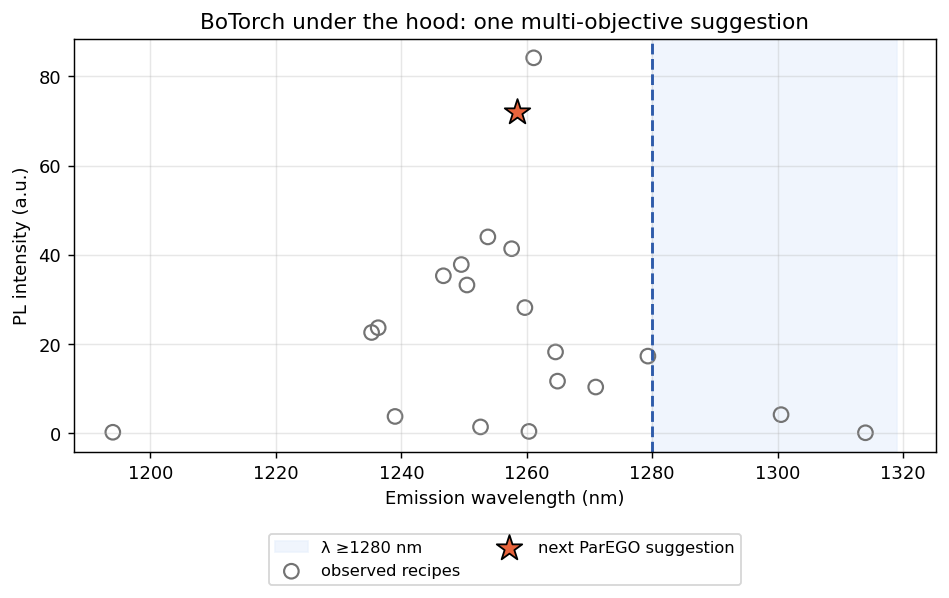

In [ ]:
#@title BoTorch single-objective and multi-objective steps { display-mode: "form" }

import warnings; warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.quasirandom import SobolEngine

from botorch.models import SingleTaskGP, ModelListGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood, SumMarginalLogLikelihood
from botorch.optim import optimize_acqf
from botorch.utils.transforms import normalize, unnormalize
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.acquisition.objective import GenericMCObjective
from botorch.utils.multi_objective.scalarization import get_chebyshev_scalarization

# qLogExpectedImprovement is the newer, numerically stable version.
# If unavailable, fall back to qExpectedImprovement.
try:
    from botorch.acquisition.logei import qLogExpectedImprovement
    EI_CLASS = qLogExpectedImprovement
    ei_name = "qLogExpectedImprovement"
except Exception:
    from botorch.acquisition.monte_carlo import qExpectedImprovement
    EI_CLASS = qExpectedImprovement
    ei_name = "qExpectedImprovement"

# qLogNParEGO is the newer log version.
# If unavailable, fall back to qNParEGO.
try:
    from botorch.acquisition.multi_objective.parego import qLogNParEGO
    PAREGO_CLASS = qLogNParEGO
    parego_name = "qLogNParEGO"
except Exception:
    from botorch.acquisition.multi_objective.parego import qNParEGO
    PAREGO_CLASS = qNParEGO
    parego_name = "qNParEGO"

torch.manual_seed(0)

# ── USER CONTROLS ────────────────────────────────────────────────────────────
n_initial_points = 8   #@param {type:"slider", min:4, max:12, step:1}
n_single_steps   = 11   #@param {type:"slider", min:4, max:16, step:1}
target_wavelength = 1280  #@param {type:"slider", min:1260, max:1300, step:5}

# ── PARAMETER BOUNDS ─────────────────────────────────────────────────────────
# Same toy growth parameters used earlier:
#   growth_temp     : 480–560 °C
#   v_iii_ratio     : 5–50
#   AsH3_fraction   : 0.10–0.50

tkw = {"dtype": torch.double}

bounds = torch.tensor(
    [
        [480.0,  5.0, 0.10],
        [560.0, 50.0, 0.50],
    ],
    **tkw
)

unit_bounds = torch.stack(
    [
        torch.zeros(3, **tkw),
        torch.ones(3, **tkw),
    ]
)


# ── TOY DEVICE FUNCTION ──────────────────────────────────────────────────────
# This is the BoTorch version of the toy device_response(...).
# In a real experiment, this would be replaced by growth + measurement.

def device_torch(X):
    growth_temp = X[:, 0]
    v_iii_ratio = X[:, 1]
    AsH3_fraction = X[:, 2]

    t = (growth_temp - 480.0) / 80.0
    v = (v_iii_ratio - 5.0) / 45.0
    a = (AsH3_fraction - 0.10) / 0.40

    broad_growth_window = 40.0 * torch.exp(
        -((t - 0.38) ** 2) / 0.22
        -((v - 0.42) ** 2) / 0.10
        -((a - 0.45) ** 2) / 0.12
    )

    high_quality_peak = 60.0 * torch.exp(
        -((t - 0.50) ** 2) / 0.006
        -((v - 0.40) ** 2) / 0.006
        -((a - 0.45) ** 2) / 0.006
    )

    pl = torch.clamp(broad_growth_window + high_quality_peak, min=0.0, max=100.0)

    wavelength = (
        1212.0
        + 50.0 * t
        - 18.0 * v
        + 70.0 * a
    )

    return torch.stack([pl, wavelength], dim=-1)


# ── INITIAL SOBOL / DoE POINTS ───────────────────────────────────────────────
sobol = SobolEngine(3, scramble=True, seed=0)

X = unnormalize(
    sobol.draw(n_initial_points).to(**tkw),
    bounds
)

Y = device_torch(X)


# ══════════════════════════════════════════════════════════════════════════════
# PART 1: SINGLE-OBJECTIVE BOTORCH LOOP
# Goal: maximise PL intensity
# ══════════════════════════════════════════════════════════════════════════════

print("BoTorch single-objective loop")
print("────────────────────────────")
print(f"Acquisition function: {ei_name}")
print("Objective: maximise PL intensity")
print()

for step in range(n_single_steps):

    # Normalise input parameters to [0, 1]
    Xn = normalize(X, bounds)

    # Use only PL intensity as the objective
    y = Y[:, 0:1]

    # Standardise objective values for GP fitting
    ys = (y - y.mean()) / y.std()

    # Fit Gaussian process
    gp = SingleTaskGP(Xn, ys)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)

    # Define acquisition function
    acqf = EI_CLASS(
        model=gp,
        best_f=ys.max()
    )

    # Optimise acquisition function to get next recipe
    candidate_unit, _ = optimize_acqf(
        acq_function=acqf,
        bounds=unit_bounds,
        q=1,
        num_restarts=5,
        raw_samples=64,
    )

    # Convert from [0, 1] back to real recipe units
    X_new = unnormalize(candidate_unit, bounds)

    # Evaluate toy device response
    Y_new = device_torch(X_new)

    # Add new result to dataset
    X = torch.cat([X, X_new])
    Y = torch.cat([Y, Y_new])


best_idx = int(Y[:, 0].argmax())

print("Best recipe found by single-objective BoTorch:")
print("────────────────────────────────────────────")
print(f"PL intensity     = {Y[best_idx, 0]:.1f} a.u.")
print(f"Emission λ       = {Y[best_idx, 1]:.1f} nm")
print(f"growth_temp      = {X[best_idx, 0]:.1f} °C")
print(f"v_iii_ratio      = {X[best_idx, 1]:.1f}")
print(f"AsH3_fraction    = {X[best_idx, 2]:.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# PART 2: ONE MULTI-OBJECTIVE PAREGO-STYLE STEP
# Goal: maximise PL intensity and emission wavelength
# ══════════════════════════════════════════════════════════════════════════════

print("\nBoTorch multi-objective step")
print("───────────────────────────")
print("Acquisition function: ParEGO-style scalarisation + qLogExpectedImprovement")
print("Objectives:")
print("  1. maximise PL intensity")
print("  2. maximise emission wavelength")
print()

Xn = normalize(X, bounds)

# Multi-objective data:
# objective 1 = PL intensity
# objective 2 = emission wavelength
Y_mo = torch.stack(
    [
        Y[:, 0],
        Y[:, 1],
    ],
    dim=-1
)

# Standardise each objective separately
Y_mo_std = (Y_mo - Y_mo.mean(dim=0)) / Y_mo.std(dim=0)

# Random scalarisation weights
# ParEGO repeatedly uses different weights to explore different trade-offs.
weights = torch.rand(2, **tkw)
weights = weights / weights.sum()

scalarization = get_chebyshev_scalarization(
    weights=weights,
    Y=Y_mo_std
)

# Convert the two objectives into one temporary scalar objective
Y_scalar = scalarization(Y_mo_std).unsqueeze(-1)

# Standardise the scalar objective for GP fitting
Y_scalar_std = (Y_scalar - Y_scalar.mean()) / Y_scalar.std()

# Fit a GP to the scalarised objective
gp_scalar = SingleTaskGP(Xn, Y_scalar_std)

mll = ExactMarginalLogLikelihood(
    gp_scalar.likelihood,
    gp_scalar
)

fit_gpytorch_mll(mll)

# Use expected improvement on the scalarised objective
parego_acqf = EI_CLASS(
    model=gp_scalar,
    best_f=Y_scalar_std.max()
)

candidate_unit, _ = optimize_acqf(
    acq_function=parego_acqf,
    bounds=unit_bounds,
    q=1,
    num_restarts=5,
    raw_samples=64,
)

X_next = unnormalize(candidate_unit, bounds)
Y_next = device_torch(X_next)

print("ParEGO-style multi-objective step proposes:")
print("──────────────────────────────────────────")
print(f"growth_temp      = {X_next[0, 0]:.1f} °C")
print(f"v_iii_ratio      = {X_next[0, 1]:.1f}")
print(f"AsH3_fraction    = {X_next[0, 2]:.3f}")
print(f"Toy PL           = {Y_next[0, 0]:.1f} a.u.")
print(f"Toy λ            = {Y_next[0, 1]:.1f} nm")

print("\nScalarisation weights used in this ParEGO step:")
print(f"  PL weight       = {weights[0]:.2f}")
print(f"  wavelength weight = {weights[1]:.2f}")

if Y_next[0, 1] >= target_wavelength:
    print(f"\nTarget check     = ✅ λ ≥ {target_wavelength} nm")
else:
    print(f"\nTarget check     = ⚠️ below {target_wavelength} nm")

# ══════════════════════════════════════════════════════════════════════════════
# SIMPLE VISUAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

Y_np = Y.detach().numpy()
Y_next_np = Y_next.detach().numpy()

fig, ax = plt.subplots(figsize=(7.4, 4.8), dpi=130)

ax.axvspan(
    target_wavelength,
    max(1310, Y_np[:, 1].max() + 5),
    color="#e8f0fc",
    alpha=0.65,
    label=f"λ ≥{target_wavelength} nm"
)

ax.axvline(
    target_wavelength,
    color="#2E5BAA",
    linestyle="--",
    lw=1.6
)

ax.scatter(
    Y_np[:, 1],
    Y_np[:, 0],
    facecolors="none",
    edgecolors="0.45",
    s=65,
    linewidth=1.2,
    label="observed recipes"
)

ax.scatter(
    Y_next_np[0, 1],
    Y_next_np[0, 0],
    marker="*",
    s=220,
    color="#E8643C",
    edgecolor="black",
    label="next ParEGO suggestion",
    zorder=5
)

ax.set_xlabel("Emission wavelength (nm)")
ax.set_ylabel("PL intensity (a.u.)")
ax.set_title("BoTorch under the hood: one multi-objective suggestion")
ax.grid(True, alpha=0.3)

ax.legend(
    fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True
)

plt.tight_layout()
plt.show()





---
## 🏁 Section 6 · Recap

### What you learned

In this notebook, we built a simplified version of a real experimental Bayesian optimisation workflow.

You have now seen how to:

- ✅ use **Latin-Hypercube DoE** to choose an initial set of recipes that covers the search space reasonably well,
- ✅ run **single-objective BO** to maximise one target, such as PL intensity,
- ✅ run **multi-objective BO** when more than one device property matters,
- ✅ interpret an **observed Pareto front** as a set of useful trade-off recipes,
- ✅ connect the Honegumi/Ax template to the lower-level BoTorch idea:
  
```text
fit GP → maximise acquisition → suggest recipe → observe result → update model
````

The key message is that BO is not a magic optimiser.
It is a structured way to decide which experiment to run next when measurements are expensive.


The toy notebook is therefore not a full physical model, but it captures the optimisation logic used in the real pipeline.

---

### Try these next

* 🔧 Change the wavelength target from `1260 nm` to `1290 nm`.
  Does the trade-off with PL become harder?

* 🔧 Try different values of `n_bo_suggestions`.
  How many BO suggestions are needed before useful recipes appear?

* 🔧 Compare `batch_size = 1`, `2`, and `4`.
  Does sequential BO find better recipes, or is batch BO more experimentally practical?

* 🔧 Add a fourth knob, such as `growth_time`.
  Does BO need more trials when the search space becomes larger?



---

### Useful links

🔗 Generate your own BO template: [honegumi.readthedocs.io](https://honegumi.readthedocs.io)

🔗 Real microring BO pipeline: [github.com/OMS-lab/Microring_MOBO](https://github.com/OMS-lab/Microring_MOBO)

🔗 Publication DOI: [10.1021/acsphotonics.5c00520](https://doi.org/10.1021/acsphotonics.5c00520)
